In [1]:
from aoespy import *
import xarray as xr
dir='/nobackupp27/afahad/exp/'
data='/nobackupp27/afahad/exp/script_replay_AGU/data/'

/home6/afahad/.local/lib/python3.9/site-packages/aoespy.py:19: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


In [2]:
rp2=xr.open_mfdataset('/nobackupp27/afahad/exp/GEOSMIT_RP0506/holding/geosgcm_prog/200505/*geosgcm_prog.*200505*z.nc4')
me2=xr.open_mfdataset('/nobackupp27/afahad/exp/GEOSMIT_ME0506/holding/geosgcm_prog/200505/*geosgcm_prog.*200505*z.nc4')

In [3]:
rp1=xr.open_mfdataset('/nobackupp27/afahad/exp/GEOSMIT_RP0506/holding/geosgcm_prog/200506/*geosgcm_prog.*200506*z.nc4')
me1=xr.open_mfdataset('/nobackupp27/afahad/exp/GEOSMIT_ME0506/holding/geosgcm_prog/200506/*geosgcm_prog.*200506*z.nc4')

In [4]:
rp=xr.concat((rp2,rp1),dim='time')
me=xr.concat((me2,me1),dim='time')

In [5]:
rp=rp[['T','QV','OMEGA']].compute()
me=me[['T','QV','OMEGA']].compute()

In [182]:
x1=-178
x2=-178
y1=2
y2=2


x1=-127
x2=-127
y1=7
y2=7

rpcpT=rp.T.sel(lon=x1,lat=y1,lev=slice(900,250))
mecpT=me.T.sel(lon=x1,lat=y1,lev=slice(900,250))

rpcpQ=rp.QV.sel(lon=x1,lat=y1,lev=slice(900,250))
mecpQ=me.QV.sel(lon=x1,lat=y1,lev=slice(900,250))

rpcpO=rp.OMEGA.sel(lon=x1,lat=y1,lev=slice(900,250))
mecpO=me.OMEGA.sel(lon=x1,lat=y1,lev=slice(900,250))

rpcpTO=rpcpT*rpcpO
mecpTO=mecpT*mecpO

rpcpQO=rpcpT*rpcpQ
mecpQO=mecpT*mecpQ


rpcpT=rpcpT[1:,:].data-rpcpT[:-1,:]
mecpT=mecpT[1:,:].data-mecpT[:-1,:]

rpcpO=rpcpO[1:,:].data-rpcpO[:-1,:]
mecpO=mecpO[1:,:].data-mecpO[:-1,:]

rpcpTO2=rpcpT*rpcpO
mecpTO2=mecpT*mecpO

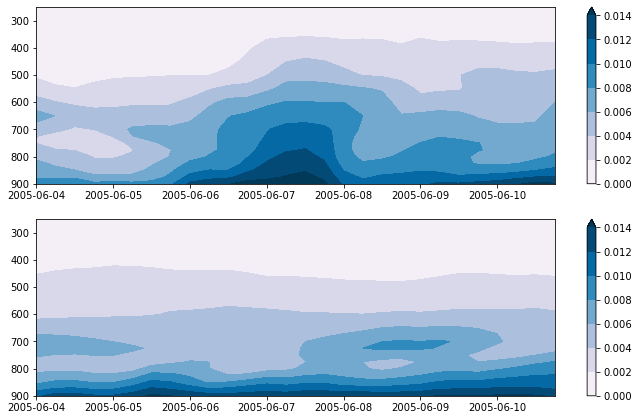

In [93]:
clf=arange(0,.015,.002)
cmap='PuBu'
f()
plt.subplot(2,1,1)
plt.contourf(mecpQ.sel(time=slice('2005-06-04','2005-06-10')).time,mecpQ.lev,mecpQ.sel(time=slice('2005-06-04','2005-06-10')).T,levels=clf,extend='max',cmap=cmap)
plt.gca().invert_yaxis()
plt.colorbar()

plt.subplot(2,1,2)
plt.contourf(mecpQ.sel(time=slice('2005-06-04','2005-06-10')).time,mecpQ.lev,rpcpQ.sel(time=slice('2005-06-04','2005-06-10')).T,levels=clf,extend='max',cmap=cmap)
plt.colorbar()
plt.gca().invert_yaxis()

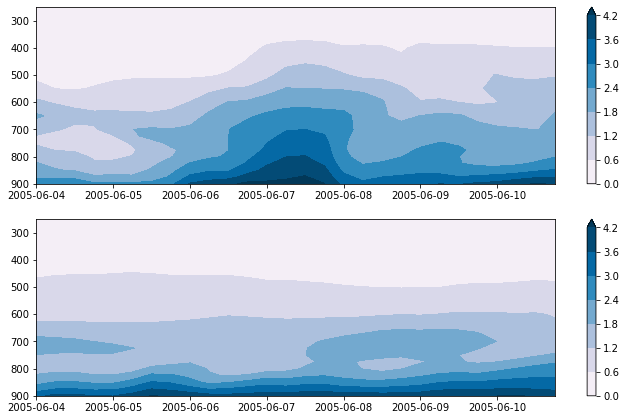

In [102]:
clf=arange(0,.015,.002)*300
cmap='PuBu'
f()
plt.subplot(2,1,1)
plt.contourf(mecpQ.sel(time=slice('2005-06-04','2005-06-10')).time,mecpQO.lev,mecpQO.sel(time=slice('2005-06-04','2005-06-10')).T,levels=clf,extend='max',cmap=cmap)
plt.gca().invert_yaxis()
plt.colorbar()

plt.subplot(2,1,2)
plt.contourf(mecpQ.sel(time=slice('2005-06-04','2005-06-10')).time,mecpQ.lev,rpcpQO.sel(time=slice('2005-06-04','2005-06-10')).T,levels=clf,extend='max',cmap=cmap)
plt.colorbar()
plt.gca().invert_yaxis()

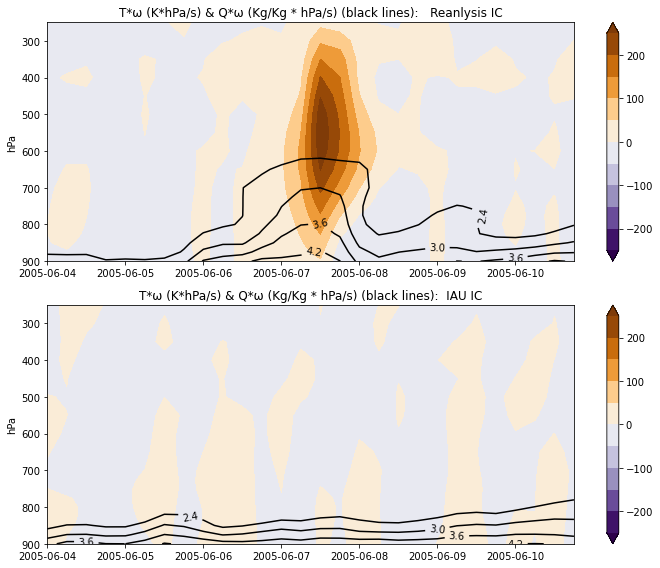

In [176]:
clf=arange(-250,251,50)
clf2=arange(0.008,.015,.002)*300
cmap='PuOr_r'
plt.figure(figsize=(10,8))
plt.subplot(2,1,1)
cs=plt.contour(mecpQ.sel(time=slice('2005-06-04','2005-06-10')).time,mecpQO.lev,mecpQO.sel(time=slice('2005-06-04','2005-06-10')).T,levels=clf2,extend='max',colors='black')
plt.ylabel('hPa')
plt.clabel(cs)
plt.contourf(mecpT.sel(time=slice('2005-06-04','2005-06-10')).time,mecpT.lev,-mecpTO.sel(time=slice('2005-06-04','2005-06-10')).T,levels=clf,extend='both',cmap=cmap)
plt.colorbar()
plt.gca().invert_yaxis()
plt.title('T*ω (K*hPa/s) & Q*ω (Kg/Kg * hPa/s) (black lines):   Reanlysis IC')


plt.subplot(2,1,2)
cs=plt.contour(mecpQ.sel(time=slice('2005-06-04','2005-06-10')).time,mecpQ.lev,rpcpQO.sel(time=slice('2005-06-04','2005-06-10')).T,levels=clf2,extend='max',colors='black')
plt.clabel(cs)
plt.ylabel('hPa')
plt.contourf(mecpT.sel(time=slice('2005-06-04','2005-06-10')).time,mecpT.lev,-rpcpTO.sel(time=slice('2005-06-04','2005-06-10')).T,levels=clf,extend='both',cmap=cmap)
plt.colorbar()
plt.title('T*ω (K*hPa/s) & Q*ω (Kg/Kg * hPa/s) (black lines):  IAU IC')
plt.gca().invert_yaxis()
plt.tight_layout()
#plt.savefig('flux_CP.png',dpi=200)

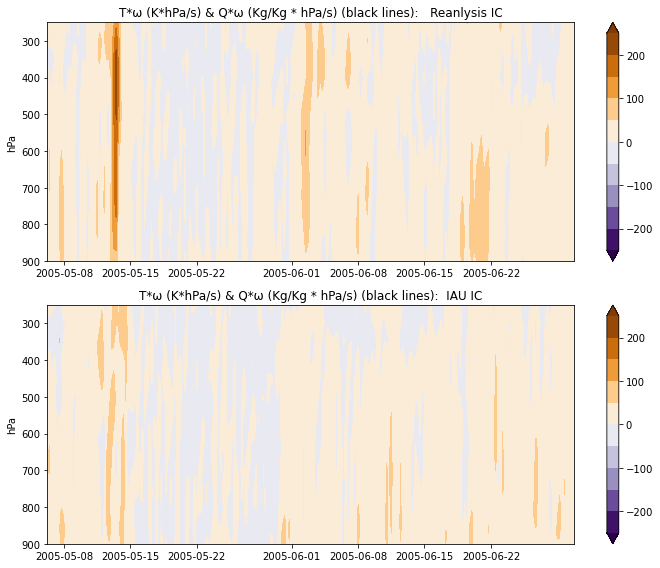

In [6]:

rpT=rp.T.sel(lev=500)
meT=me.T.sel(lev=500)

# rpcpQ=rp.QV.sel(lon=x1,lat=y1,lev=slice(900,250))
# mecpQ=me.QV.sel(lon=x1,lat=y1,lev=slice(900,250))

rpO=rp.OMEGA.sel(lev=500)
meO=me.OMEGA.sel(lev=500)

rpTO=-rpT*rpO
meTO=-meT*meO


In [198]:

rpT=rp.T.sel(lev=400)
meT=me.T.sel(lev=400)

# rpcpQ=rp.QV.sel(lon=x1,lat=y1,lev=slice(900,250))
# mecpQ=me.QV.sel(lon=x1,lat=y1,lev=slice(900,250))

rpO=rp.OMEGA.sel(lev=400)
meO=me.OMEGA.sel(lev=400)

rpTO=-rpT*rpO
meTO=-meT*meO


In [199]:
# plt.figure(figsize=(10,8))
# # plt.subplot(2,1,1)
# # (rpcpTO.sel(time='2005-06-07',lat=slice(-10,10),lon=slice(-180,-100))[2,:,:]*-1).plot(levels=array([-300,-250,-200,200,250,300]),extend='both')

# plt.subplot(2,1,1)
# (mecpTO.sel(time='2005-05-12',lat=slice(-10,10),lon=slice(-180,-100))[2,:,:]*-1).plot(levels=array([-300,-250,-200,200,250,300]),extend='both')

# plt.subplot(2,1,2)
# (mecpTO.sel(time='2005-05-14',lat=slice(-10,10),lon=slice(-180,-100))[2,:,:]*-1).plot(levels=array([-300,-250,-200,200,250,300]),extend='both')

In [7]:
ticks=[]

for i in range(len(rpTO.time)):
    ticks=append(ticks,str(rpTO.time.data[i])[5:10])

In [ ]:

x1=-127
x2=-127
y1=7
y2=7

# x1=-116
# x2=-115
# y1=5
# y2=5

plt.figure(figsize=(11,6.5))
plt.subplot(2,3,1)

plt.plot((meTO).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')
plt.plot((rpTO).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')

plt.title('Eastern Tropical Pacific')
plt.xticks(arange(len(ticks))[::40],ticks[::40],fontsize=8);
plt.legend(['Reanlysis IC', 'IAU IC'])
plt.xlabel('Date (month-day)')
plt.ylabel('K*hPa/s')


x1=-178
x2=-178
y1=2
y2=2

plt.subplot(2,3,2)
# plt.plot((ME426P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')
# plt.plot((RP426P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')

plt.plot((meTO).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')
#plt.plot((ME511P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')

plt.plot((rpTO).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')
#plt.plot((RP511P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')
plt.title('Central Tropical Pacific')
plt.xticks(arange(len(ticks))[::40],ticks[::40],fontsize=8);
plt.xlabel('Date (month-day)')
plt.ylabel('K*hPa/s')

# x1=136
# x2=137
# y1=3
# y2=4

x1=143
x2=143
y1=-1
y2=-1

plt.subplot(2,3,3)
# plt.plot((ME426P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')
# plt.plot((RP426P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')

plt.plot((meTO).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')
#plt.plot((ME511P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')

plt.plot((rpTO).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')
#plt.plot((RP511P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')
plt.title('Western Tropical Pacific')
plt.xticks(arange(len(ticks))[::40],ticks[::40],fontsize=8);
plt.xlabel('Date (month-day)')
plt.ylabel('K*hPa/s')

x1=89
x2=92
y1=7
y2=8



plt.subplot(2,3,4)
# plt.plot((ME426P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')
# plt.plot((RP426P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')

plt.plot((meTO).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')
#plt.plot((ME511P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')

plt.plot((rpTO).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')
#plt.plot((RP511P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')
plt.title('Tropical Indian Ocean')
plt.xticks(arange(len(ticks))[::40],ticks[::40],fontsize=8);
plt.xlabel('Date (month-day)')
plt.ylabel('K*hPa/s')

x1=-39
x2=-38
y1=7
y2=8



plt.subplot(2,3,5)
# plt.plot((ME426P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')
# plt.plot((RP426P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')

plt.plot((meTO).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')
#plt.plot((ME511P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')

plt.plot((rpTO).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')
#plt.plot((RP511P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')
plt.title('Tropical Atlantic Ocean')
plt.xticks(arange(len(ticks))[::40],ticks[::40],fontsize=8);
plt.xlabel('Date (month-day)')
plt.ylabel('K*hPa/s')

x1=90
x2=91
y1=23
y2=25

# plt.subplot(2,3,6)
# # plt.plot((ME426P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')
# # plt.plot((RP426P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')

# plt.plot((meTO).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='blue')
# #plt.plot((ME511P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')

# plt.plot((rpTO).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')
# #plt.plot((RP511P).sel(lat=slice(y1,y2),lon=slice(x1,x2)).mean(dim=['lon','lat']),color='orange')
# plt.title('Indian Monsoon')
# plt.xticks(arange(len(ticks))[::40],ticks[::40],fontsize=8);
# plt.xlabel('Date (month-day)')
# plt.ylabel('K*hPa/s')

# x1=32
# x2=35
# y1=-1
# y2=2


plt.suptitle('T*ω 500hPa (K*hPa/s) ', fontweight='bold', fontsize=14)

plt.tight_layout()
plt.savefig('/nobackupp27/afahad/scripts/initialization_shock/spike_t_omega.png',dpi=150)